In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pyamps
import dipole
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import polplot
from pyamps.plot_utils import Polarsubplot
from pyamps import AMPS
from datetime import datetime, timedelta
import warnings
import glob
warnings.filterwarnings('ignore')

from IPython.display import clear_output


In [2]:
RE = 6371.2e3
RI = RE + 110e3

theta0 = 0.25 # for j_G matrix singularity limit

Epoch = 2023 # REMEMBER TO CHANGE TO FIT DATA

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
L, W, Lres, Wres = 4500e3,3500e3,30,25

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,90))

# Define meridian
mlon_m = 50
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*mlon_m

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [3]:
# Matrices to get predictions of B on meridian
depth = 400.0e3
#GeB_m, GnB_m, GuB_m = get_SECS_B_G_matrices(meridian_lat_geo, meridian_lon_geo, RE, grid.lat.flatten(), grid.lon.flatten())
GeB_m, GnB_m, GuB_m = get_SECS_B_G_matrices(meridian_lat_geo, meridian_lon_geo, RE, grid.lat.flatten(), grid.lon.flatten(), induction_nullification_radius = RE - depth)

# Matrices to get predictions of j on meridian
Gej_m, Gnj_m = get_SECS_J_G_matrices(meridian_lat_geo, meridian_lon_geo, grid.lat.flatten(), grid.lon.flatten(), singularity_limit = theta0 * np.pi / 180 * RI)

**INTERACTIVE PLOTTING**

In [12]:
times_sup = np.load('concurrent_times_supermag.npy',allow_pickle=True)
times_dtu = np.load('concurrent_times_dtu_minute.npy',allow_pickle=True)
times = np.intersect1d(times_sup, times_dtu)

In [19]:
import glob
import os

# Your accepted times array
accepted_times = times  # modify as needed

# Your three folders
folders = [
    "supermag_downloads/yearly_BASELINE/2023",
    "supermag_downloads/yearly_BASELINE/2024",
    "supermag_downloads/yearly_BASELINE/2025",
]

all_dfs = []
for folder in folders:
    csv_files = glob.glob(os.path.join(folder, "*SUM*.csv"))
    if csv_files:
        all_dfs.append(pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True))

df_mag = pd.concat(all_dfs, ignore_index=True)

# Filter to accepted times only
df_mag['time'] = pd.to_datetime(df_mag['time'])
df_mag = df_mag[df_mag["time"].isin(accepted_times)]

# Sort by time then iaga
df_mag = df_mag.sort_values(by=["time"]).reset_index(drop=True)

In [ ]:
df_mag.head()

,time,ext,iaga,dbn_geo,dbe_geo,dbz_geo
0,2023-02-23 13:59:00,60.0,SUM,31.983765,43.278309,-100.417006
1,2023-02-23 14:00:00,60.0,SUM,38.274233,30.568524,-121.256868
2,2023-02-23 14:02:00,60.0,SUM,26.189047,18.484526,-136.124093
3,2023-02-23 14:03:00,60.0,SUM,15.027348,21.474225,-133.506924
4,2023-02-23 14:10:00,60.0,SUM,30.283408,30.450096,-131.124242


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_mag['time'].values, y=df_mag['dbz_geo'].values, mode="lines", name="My Series"))

fig.update_layout(
    title="Interactive Time Series",
    xaxis_title="Date",
    yaxis_title="Value",
    xaxis=dict(rangeslider=dict(visible=True)),  # adds a range slider!
)

fig.show()

**INTERESSANTE TIDER:**
<br>
*ULF WAVES?:*
<br>
Nov 29 2024 10:00-13:00
<br>
Dec 2 2024 08:00-12:00
<br>
Dec 3 2024 10:00-14:00
<br>
Dec 4 2024 09:00-13:00
<br>
Dec 12 2024 09:00-12:00 (meget tydelig tror jeg)
<br>
Apr 30 2025 11:00-13:00 (meget tydelig tror jeg)
<br>
*Geomagnetic storm?:*
<br>
Apr 24 2025 07:00-15:00
<br>
Også meget aktivitet i 1-5 May 2025
<br>
*Substorm?:*
<br>
Nov 30 2024 00:00-03:00

**NOW LOAD ALL MAGS FOR INTERESTING TIME**

In [4]:
import gc
import glob
import os
accepted_times = np.load('concurrent_times_supermag.npy', allow_pickle=True)

# Load all CSVs from folder

all_dfs = []
for folder in ['2024']:
    csv_files = glob.glob(os.path.join('supermag_downloads/yearly_BASELINE', folder, "*2024_11*.csv"))
    if csv_files:
        all_dfs.append(pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True))

df_mag = pd.concat(all_dfs, ignore_index=True)

del all_dfs
gc.collect()

df_mag['time'] = pd.to_datetime(df_mag['time'])

# Filter to accepted times only
df_mag = df_mag[df_mag["time"].isin(accepted_times)]

# Sort by time then iaga
df_mag = df_mag.sort_values(by=["time", "iaga"]).reset_index(drop=True)


In [5]:
df_mag = df_mag.rename(columns={'time': 'Date_UTC', 'iaga': 'IAGA'})
df_mag.head()

,Date_UTC,ext,IAGA,dbn_geo,dbe_geo,dbz_geo
0,2024-11-08 13:18:00,60.0,BJN,2.137945,-8.991595,-6.485392
1,2024-11-08 13:18:00,60.0,DMH,-79.678636,7.222705,-35.300297
2,2024-11-08 13:18:00,60.0,GDH,-18.032152,8.761926,-17.237859
3,2024-11-08 13:18:00,60.0,HOP,-0.828249,-4.084991,-27.224976
4,2024-11-08 13:18:00,60.0,HOV,-29.294152,-14.275211,-6.602701


In [6]:
nan_counts = (
    df_mag[df_mag['dbn_geo'].isna()]
    .groupby('IAGA')
    .size()
)
nan_counts

Series([], dtype: int64)

In [27]:
## REMOVE TIMES WHERE REMAINING NANS ARE
na_mask = df_mag['dbn_geo'].isna()
times_na = df_mag['Date_UTC'][na_mask]
df_mag = df_mag[~df_mag['Date_UTC'].isin(times_na)]
print('Shape with no nans:',df_mag.shape)

Shape with no nans: (0, 7)


In [ ]:
na_mask = df_mag['dbn_geo'].isna()
df_mag_na = df_mag[na_mask]
for stat in df_mag_na['IAGA'].unique():
    df_temp = df_mag_na[df_mag_na['IAGA']==stat]
    print(df_temp.shape[0])


df_mag_na['IAGA'].unique()

<ArrowStringArray>
[]
Length: 0, dtype: str

In [33]:
## REMOVE STATIONS WITH MANY NANS
# Count NaNs in dbn_geo per station
nan_counts = (
    df_mag[df_mag['dbn_geo'].isna()]
    .groupby('IAGA')
    .size()
)

# Find stations with more than 50000 NaNs
stations_to_remove = nan_counts[nan_counts > 1000].index

print("Stations to remove:")
print(stations_to_remove)

# Remove ALL data from those stations
df_mag = df_mag[
    ~df_mag['IAGA'].isin(stations_to_remove)
]

## REMOVE TIMES WHERE REMAINING NANS ARE
na_mask = df_mag['dbn_geo'].isna()
times_na = df_mag['Date_UTC'][na_mask]
df_mag = df_mag[~df_mag['Date_UTC'].isin(times_na)]

Stations to remove:
Index(['KUV', 'NAN', 'RES', 'THL'], dtype='str', name='IAGA')


In [6]:
stations = df_mag['IAGA'].unique()
times = df_mag['Date_UTC'].unique()

df_mag['dbu_geo'] = -df_mag['dbz_geo']

# Pivot the entire DataFrame at once
# Rows = Stations, Columns = Time, Values = The 3 components
pivoted = df_mag.pivot(index='IAGA', columns='Date_UTC', 
                                values=['dbe_geo', 'dbn_geo', 'dbu_geo'])

# Ensure the rows (stations) and columns (time) stay in original order
pivoted = pivoted.reindex(index=stations, columns=times, level=1)

# Extract the three (21 x T) blocks and stack them vertically
# pivoted['column_name'] returns a (21, T) array
d = np.vstack([
    pivoted['dbe_geo'].values, 
    pivoted['dbn_geo'].values, 
    pivoted['dbu_geo'].values
])

# convert to nT
d = d * 1e-9

In [7]:
# Path to your CSV file
file_path = "SuperMAG_stations.csv"

# Read CSV
df = pd.read_csv(file_path)

# Make sure column names match your file exactly
# Adjust these if necessary after checking df.columns
iaga_column = "IAGA"
lat_column = "GLAT"
lon_column = "GLON"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df[df[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()

In [8]:
depth = 400e3 # depth where Br = 0 [m]
GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
#GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)

# G matrix for the mirror current method:
G_mirror = np.vstack((GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror)) # shape: (3*N, grid.size)

# Approach number 2: East-west minimization
Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid) # get matrices that calculate MAGNETIC eastward and northward components of gradient
GTG_mirror, GTd_mirror = G_mirror.T.dot(G_mirror), G_mirror.T.dot(d) # we multiply the set of equations by G_mirror transpose
LTL = LTLe
T0, T1 = 8e-24, 1e-21 # regularization parameters from Walker
#T0, T1 = 1e-23, 1e-10 # less east/west reg
R = T0 * np.eye(grid.size) + T1 * LTL # regularization matrix
I_mirror = np.linalg.lstsq(GTG_mirror + R, GTd_mirror, rcond = 0)[0]

# Model predictions at meridian
Bu_m = GuB_m.dot(I_mirror)
je_m, jn_m = Gej_m.dot(I_mirror), Gnj_m.dot(I_mirror)

# GETTING MLT FOR EACH TIME/MERIDAN:
mlt = pyamps.mlon_to_mlt(mlon_m, times, Epoch)


In [9]:
df_b = pd.DataFrame(columns=['time','MLT','clock_angle','Br','je','jn'])
df_b['time'] = times
#df_b.set_index('time', inplace=True)
df_b = df_b.sort_index()

df_b['MLT'] = mlt
df_b['Br'] = [Bu_m[:, i] for i in range(Bu_m.shape[1])]
df_b['je'] = [je_m[:, i] for i in range(je_m.shape[1])]
df_b['jn'] = [jn_m[:, i] for i in range(jn_m.shape[1])]

df_b.head()

,time,MLT,clock_angle,Br,je,jn
0,2024-11-08 13:18:00,12.172591,NaN,"[1.1387004514012624e-08, 1.1339576585988168e-0...","[-0.00501663852560532, -0.007659553593035702, ...","[-0.005977401865415843, -0.0052831172131168405..."
1,2024-11-08 13:19:00,12.188698,NaN,"[1.1177856661046338e-08, 1.1126397054290807e-0...","[-0.005648592266656002, -0.008275079178646153,...","[-0.005042677888567475, -0.004344879412230312,..."
2,2024-11-08 13:20:00,12.204806,NaN,"[1.1035607773845875e-08, 1.098483220389067e-08...","[-0.0063455501276116055, -0.00895622829229924,...","[-0.00455724554041607, -0.0038586628833932597,..."
3,2024-11-08 13:21:00,12.220912,NaN,"[1.0636479517992412e-08, 1.059169762467422e-08...","[-0.006768276093987918, -0.009284377537816569,...","[-0.0035552162770060556, -0.002869347531003081..."
4,2024-11-08 13:22:00,12.237018,NaN,"[1.1010094220092718e-08, 1.097441621919425e-08...","[-0.006256360778692644, -0.008819998557046566,...","[-0.003730965539982477, -0.0030282882007374797..."


In [10]:
window = 3  # adjust as needed

for col in ['Br', 'je', 'jn']:
    # Expand lists into 2D array (time x meridian points)
    arr = np.array(df_b[col].tolist())
    
    # Compute rolling mean for each meridian point
    df_arr = pd.DataFrame(arr)
    rolling_mean = df_arr.rolling(window=window, center=True, min_periods=1).mean()
    
    # Subtract running mean
    result = arr - rolling_mean.values
    
    # Store back as lists in a new column
    df_b[f'{col}_hf'] = [row for row in result]

In [12]:
df_b_plot = df_b[(df_b['time'] >= datetime(2024,11,30,1,20)) & (df_b['time'] <= datetime(2024,11,30,1,30))]
#df_b_plot = df_b_plot[(df_b['MLT'] >= 21.094) & (df_b_plot['MLT'] <= 23.9)]
#df_b_plot = df_b_plot[(df_b['MLT'] >= 22.68) & (df_b_plot['MLT'] <= 22.78)]

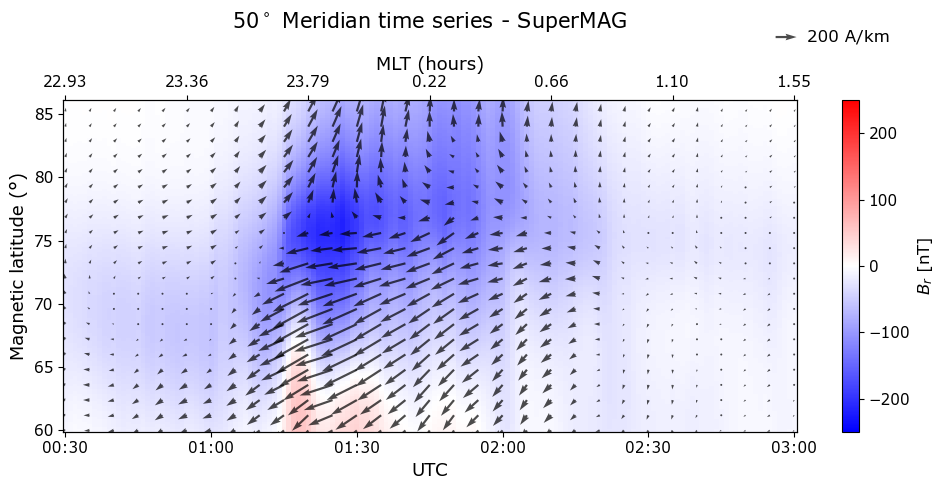

In [ ]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.tri as tri
import matplotlib.dates as mdates

# Font size constants — tweak these to taste
FS_LABEL  = 13   # axis labels
FS_TICK   = 11   # tick labels
FS_TITLE  = 15   # title
FS_CBAR   = 12   # colorbar label
FS_QKEY   = 12   # quiver key label

# Your magnetic latitude array (shape: N_mlat)
mlat = meridian_lat_qd

# Stack the Br arrays into a 2D grid: shape (n_times, n_mlat)
Br_matrix = np.stack(df_b_plot['Br'].values * 1e9)   # shape: (n_times, n_mlat)
mlt_vals  = df_b_plot['MLT'].values         # shape: (n_times,)

# Build meshgrid for contourf
MLT_grid, MLAT_grid = np.meshgrid(mlt_vals, mlat, indexing='ij')

# Downsampling strides — tune these to taste
stride_mlt  = 5
stride_mlat = 6

# Stack je and jn the same way as Br
je_matrix = np.stack(df_b_plot['je'].values * 1e3)
jn_matrix = np.stack(df_b_plot['jn'].values * 1e3)

# Slice grids and vector components together
MLT_q  =  MLT_grid[::stride_mlt, ::stride_mlat]
MLAT_q = MLAT_grid[::stride_mlt, ::stride_mlat]
je_q   =   je_matrix[::stride_mlt, ::stride_mlat]
jn_q   =   jn_matrix[::stride_mlt, ::stride_mlat]

# Use UTC timestamps as x-axis base
utc_vals = df_b_plot['time'].values

# Build meshgrid with UTC on x
UTC_grid, MLAT_grid = np.meshgrid(utc_vals, mlat, indexing='ij')
UTC_q = UTC_grid[::stride_mlt, ::stride_mlat]

fig, ax = plt.subplots(figsize=(10, 5))

vmax = np.nanmax(np.abs(Br_matrix))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf = ax.pcolormesh(
    UTC_grid, MLAT_grid, Br_matrix,
    cmap='bwr', norm=norm, shading='auto'
)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('$B_r$ [nT]', fontsize=FS_CBAR)
cbar.ax.tick_params(labelsize=FS_TICK)

quiv = ax.quiver(
    UTC_q, MLAT_q,
    je_q, jn_q,
    color='k', scale=None,
    width=0.003, alpha=0.7
)
ax.quiverkey(quiv, X=1.0, Y=1.19, U=200,
             label='200 A/km', labelpos='E',
             fontproperties={'size': FS_QKEY})

# Bottom x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_xlabel('UTC', fontsize=FS_LABEL)
ax.set_ylabel('Magnetic latitude (°)', fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)

# Top x-axis: MLT
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

tick_step = len(utc_vals) // 6
tick_indices = np.arange(0, len(utc_vals), tick_step)
ax_top.set_xticks([mdates.date2num(utc_vals[i]) for i in tick_indices])
ax_top.set_xticklabels([f'{mlt_vals[i]:.2f}' for i in tick_indices])
ax_top.set_xlabel('MLT (hours)', fontsize=FS_LABEL)
ax_top.tick_params(axis='x', labelsize=FS_TICK)

ax.set_title('$50^\circ$ Meridian time series - SuperMAG',
             size=FS_TITLE, pad=20)
plt.tight_layout()
plt.savefig('meridian_time_series/20241130_sup.png')
plt.show()

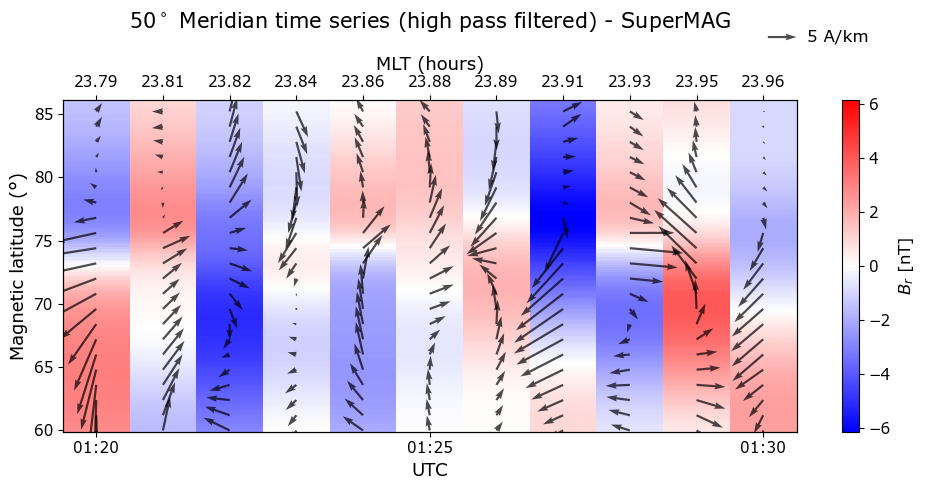

In [18]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.tri as tri
import matplotlib.dates as mdates
# Font size constants — tweak these to taste
FS_LABEL  = 13   # axis labels
FS_TICK   = 11   # tick labels
FS_TITLE  = 15   # title
FS_CBAR   = 12   # colorbar label
FS_QKEY   = 12   # quiver key label

# Your magnetic latitude array (shape: N_mlat)
mlat = meridian_lat_qd

# Stack the Br arrays into a 2D grid: shape (n_times, n_mlat)
Br_matrix = np.stack(df_b_plot['Br_hf'].values * 1e9)   # shape: (n_times, n_mlat)
mlt_vals  = df_b_plot['MLT'].values         # shape: (n_times,)

# Build meshgrid for contourf
MLT_grid, MLAT_grid = np.meshgrid(mlt_vals, mlat, indexing='ij')

# Downsampling strides — tune these to taste
stride_mlt  = 1
stride_mlat = 6

# Stack je and jn the same way as Br
je_matrix = np.stack(df_b_plot['je_hf'].values * 1e3)
jn_matrix = np.stack(df_b_plot['jn_hf'].values * 1e3)

# Slice grids and vector components together
MLT_q  =  MLT_grid[::stride_mlt, ::stride_mlat]
MLAT_q = MLAT_grid[::stride_mlt, ::stride_mlat]
je_q   =   je_matrix[::stride_mlt, ::stride_mlat]
jn_q   =   jn_matrix[::stride_mlt, ::stride_mlat]

# Use UTC timestamps as x-axis base
utc_vals = df_b_plot['time'].values

# Build meshgrid with UTC on x
UTC_grid, MLAT_grid = np.meshgrid(utc_vals, mlat, indexing='ij')
UTC_q = UTC_grid[::stride_mlt, ::stride_mlat]

fig, ax = plt.subplots(figsize=(10, 5))

vmax = np.nanmax(np.abs(Br_matrix))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf = ax.pcolormesh(
    UTC_grid, MLAT_grid, Br_matrix,
    cmap='bwr', norm=norm, shading='auto'
)
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('$B_r$ [nT]', fontsize=FS_CBAR)
cbar.ax.tick_params(labelsize=FS_TICK)

quiv = ax.quiver(
    UTC_q, MLAT_q,
    je_q, jn_q,
    color='k', scale=None,
    width=0.003, alpha=0.7
)
ax.quiverkey(quiv, X=1.0, Y=1.19, U=5,
             label='5 A/km', labelpos='E',
             fontproperties={'size': FS_QKEY})

# Bottom x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.set_xlabel('UTC', fontsize=FS_LABEL)
ax.set_ylabel('Magnetic latitude (°)', fontsize=FS_LABEL)
ax.tick_params(axis='both', labelsize=FS_TICK)

# Top x-axis: MLT
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

tick_step = len(utc_vals) // 6
tick_indices = np.arange(0, len(utc_vals), tick_step)
ax_top.set_xticks([mdates.date2num(utc_vals[i]) for i in tick_indices])
ax_top.set_xticklabels([f'{mlt_vals[i]:.2f}' for i in tick_indices])
ax_top.set_xlabel('MLT (hours)', fontsize=FS_LABEL)
ax_top.tick_params(axis='x', labelsize=FS_TICK)

ax.set_title('$50^\circ$ Meridian time series (high pass filtered) - SuperMAG',
             size=FS_TITLE, pad=20)
plt.tight_layout()
plt.savefig('meridian_time_series/20241130_sup_high_freq.png')
plt.show()